# Region and Locset Filters

This notebook is intentionally small-step: prepare a few morphology presets, define a small set of visualization knobs, then use short calls to show what each filter expression selects.

The most important split is:

- **Region filters** select branch intervals and are used by `Cell.paint(...)`.
- **Locset filters** select branch-local points and are used by `Cell.place(...)`.

Before the filters themselves, we first make the visualization level and CV policy explicit so every plot is easy to adjust.


In [1]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')
os.environ.setdefault('MPLBACKEND', 'Agg')

from collections import Counter
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import brainunit as u
import braincell
import braincell.mech as mech
from braincell import Morphology, Cell, CVPerBranch
from braincell.filter import (
    AllRegion,
    EmptyRegion,
    BranchSlice,
    BranchInFilter,
    BranchRangeFilter,
    AtLocation,
    RootLocation,
    BranchPoints,
    Terminals,
    UniformSamples,
    RandomSamples,
    at,
    branch_in,
    branch_range,
)

warnings.filterwarnings(
    'ignore',
    message=r'from_points\(\) produced .* zero-length segment',
)

plt.rcParams['figure.dpi'] = 120


## 1. Prepare Morphology Presets

The examples move from a tiny tree to richer real morphologies. Later code cells only refer to these variables.


In [2]:
repo_root = Path(braincell.__file__).resolve().parents[1]
morpho_dir = repo_root / 'data' / 'morphology' 

morph_simple = Morphology.from_swc(morpho_dir / 'example_tree.swc')
morph_io = Morphology.from_swc(morpho_dir / 'io.swc')
morph_pc = Morphology.from_asc(morpho_dir / 'pc.asc')

MORPH_PRESETS = {
    'morph_simple': morph_simple,
    'morph_io': morph_io,
    'morph_pc': morph_pc,
}


def describe_morph(name, morph):
    type_count = dict(sorted(Counter(branch.type for branch in morph.branches).items()))
    print(f'{name:<12} branches={len(morph.branches):>4}  root={morph.root.name:<10}  types={type_count}')


for name, morph in MORPH_PRESETS.items():
    describe_morph(name, morph)


--No graphics will be displayed.


morph_simple branches=   9  root=soma        types={'axon': 2, 'basal_dendrite': 6, 'soma': 1}
morph_io     branches=  31  root=soma        types={'basal_dendrite': 25, 'soma': 6}
morph_pc     branches= 461  root=soma        types={'dendrite': 460, 'soma': 1}


## 2. Visualization Knobs and Display Helpers

`Cell.vis_topology(...)` can render the same selection at three topology levels:

- `level='node'`: runtime point-tree view. Attachment points, CV midpoints, and branch terminal points can all be visible.
- `level='cv'`: one node per control volume. This is the default for region examples in this notebook because it shows partial branch coverage clearly.
- `level='branch'`: one node per morphology branch. This is compact and useful for branch metadata filters. Locsets cannot be drawn at branch level.

The CV view depends on the control-volume policy. Here the global default is `CVPerBranch(cv_per_branch=2)`, meaning each branch is split into two CVs for the visualization cell. Change the constants below and rerun later cells to compare different settings.

Each `compare_regions(...)` / `compare_locsets(...)` call also accepts per-panel overrides, so one row can compare different `level`, `layout`, `cv_per_branch`, or even different morphologies.


In [3]:
CELL_CACHE = {}
MORPH_NAMES = {id(morph): name for name, morph in MORPH_PRESETS.items()}
COLORS = ('#ef4444', '#0ea5e9', '#22c55e', '#f59e0b', '#a855f7', '#14b8a6')

# Global plot defaults. Change these and rerun later cells when comparing views.
DEFAULT_MORPH = morph_simple
DEFAULT_REGION_LEVEL = 'cv'
DEFAULT_REGION_LAYOUT = 'twopi'
DEFAULT_LOCSET_LEVEL = 'node'
DEFAULT_LOCSET_LAYOUT = 'kamada_kawai'
DEFAULT_CV_PER_BRANCH = 2
DEFAULT_LAYOUT_SCALE = 1.5
DEFAULT_PANEL_WIDTH = 3.8
DEFAULT_PANEL_HEIGHT = 3.4


def morph_name(morph):
    return MORPH_NAMES.get(id(morph), 'morph')


def resolve_morph(morph):
    if morph is None:
        return DEFAULT_MORPH
    if isinstance(morph, str):
        return MORPH_PRESETS[morph]
    return morph


def get_cell(morph, *, cv_per_branch=None):
    cv_per_branch = DEFAULT_CV_PER_BRANCH if cv_per_branch is None else cv_per_branch
    key = (id(morph), int(cv_per_branch))
    if key not in CELL_CACHE:
        cell = Cell(morph, cv_policy=CVPerBranch(cv_per_branch=int(cv_per_branch)))
        cell.init_state()
        CELL_CACHE[key] = cell
    return CELL_CACHE[key]


def _spec_from_item(item, *, default_morph, default_level, default_layout, default_cv_per_branch, default_layout_scale):
    if isinstance(item, dict):
        spec = dict(item)
    else:
        label, expr = item
        spec = {'label': label, 'expr': expr}
    spec['morph'] = resolve_morph(spec.get('morph', default_morph))
    spec['level'] = spec.get('level', default_level)
    spec['layout'] = spec.get('layout', default_layout)
    spec['preset'] = spec.get('preset', None)
    spec['layout_scale'] = spec.get('layout_scale', default_layout_scale)
    spec['cv_per_branch'] = spec.get('cv_per_branch', default_cv_per_branch)
    return spec


def _topology_kwargs(spec, *, ax, highlight_color):
    kwargs = {
        'level': spec['level'],
        'highlight_color': highlight_color,
        'node_color': '#d1d5db',
        'edge_color': '#e5e7eb',
        'root_color': '#000000',
        'ax': ax,
        'show': False,
    }
    if spec.get('layout') is not None:
        kwargs['layout'] = spec['layout']
    if spec.get('preset') is not None:
        kwargs['preset'] = spec['preset']
    if spec.get('layout_scale') is not None:
        kwargs['layout_scale'] = spec['layout_scale']
    return kwargs


def _plot_title(spec):
    return f"{spec['label']}\n{morph_name(spec['morph'])} | {spec['level']} | cv={spec['cv_per_branch']}"


def compare_regions(
    morph=None,
    labeled_exprs=(),
    *,
    level=None,
    layout=None,
    cv_per_branch=None,
    layout_scale=None,
    width=None,
    height=None,
):
    base_morph = resolve_morph(morph)
    base_level = DEFAULT_REGION_LEVEL if level is None else level
    base_layout = DEFAULT_REGION_LAYOUT if layout is None else layout
    base_cv_per_branch = DEFAULT_CV_PER_BRANCH if cv_per_branch is None else cv_per_branch
    base_layout_scale = DEFAULT_LAYOUT_SCALE if layout_scale is None else layout_scale
    specs = [
        _spec_from_item(
            item,
            default_morph=base_morph,
            default_level=base_level,
            default_layout=base_layout,
            default_cv_per_branch=base_cv_per_branch,
            default_layout_scale=base_layout_scale,
        )
        for item in labeled_exprs
    ]
    width = DEFAULT_PANEL_WIDTH if width is None else width
    height = DEFAULT_PANEL_HEIGHT if height is None else height

    fig, axes = plt.subplots(1, len(specs), figsize=(width * len(specs), height))
    axes = [axes] if len(specs) == 1 else list(axes)

    print(
        'compare_regions defaults:',
        f'morph={morph_name(base_morph)}',
        f'level={base_level}',
        f'layout={base_layout}',
        f'cv_per_branch={base_cv_per_branch}',
    )
    for index, spec in enumerate(specs):
        spec_morph = spec['morph']
        expr = spec['expr']
        mask = spec_morph.select(expr)
        print(
            f"  {spec['label']:<28}",
            f"morph={morph_name(spec_morph):<12}",
            f"level={spec['level']:<6}",
            f"layout={str(spec['layout'] or spec['preset']):<12}",
            f"cv_per_branch={spec['cv_per_branch']:<2}",
            f"intervals={len(mask.intervals):>4}",
            f"sample={mask.intervals[:4]}",
        )
        cell = get_cell(spec_morph, cv_per_branch=spec['cv_per_branch'])
        kwargs = _topology_kwargs(spec, ax=axes[index], highlight_color=COLORS[index % len(COLORS)])
        kwargs['region'] = expr
        kwargs['coverage_mode'] = spec.get('coverage_mode', 'fraction')
        cell.vis_topology(**kwargs)
        axes[index].set_title(_plot_title(spec), fontsize=9)
    plt.tight_layout()
    plt.show()


def compare_locsets(
    morph=None,
    labeled_exprs=(),
    *,
    level=None,
    layout=None,
    cv_per_branch=None,
    layout_scale=None,
    width=None,
    height=None,
):
    base_morph = resolve_morph(morph)
    base_level = DEFAULT_LOCSET_LEVEL if level is None else level
    base_layout = DEFAULT_LOCSET_LAYOUT if layout is None else layout
    base_cv_per_branch = DEFAULT_CV_PER_BRANCH if cv_per_branch is None else cv_per_branch
    base_layout_scale = DEFAULT_LAYOUT_SCALE if layout_scale is None else layout_scale
    specs = [
        _spec_from_item(
            item,
            default_morph=base_morph,
            default_level=base_level,
            default_layout=base_layout,
            default_cv_per_branch=base_cv_per_branch,
            default_layout_scale=base_layout_scale,
        )
        for item in labeled_exprs
    ]
    width = DEFAULT_PANEL_WIDTH if width is None else width
    height = DEFAULT_PANEL_HEIGHT if height is None else height

    fig, axes = plt.subplots(1, len(specs), figsize=(width * len(specs), height))
    axes = [axes] if len(specs) == 1 else list(axes)

    print(
        'compare_locsets defaults:',
        f'morph={morph_name(base_morph)}',
        f'level={base_level}',
        f'layout={base_layout}',
        f'cv_per_branch={base_cv_per_branch}',
    )
    for index, spec in enumerate(specs):
        if spec['level'] == 'branch':
            raise ValueError("Locsets can be visualized with level='node' or level='cv', not level='branch'.")
        spec_morph = spec['morph']
        expr = spec['expr']
        mask = spec_morph.select(expr)
        print(
            f"  {spec['label']:<28}",
            f"morph={morph_name(spec_morph):<12}",
            f"level={spec['level']:<6}",
            f"layout={str(spec['layout'] or spec['preset']):<12}",
            f"cv_per_branch={spec['cv_per_branch']:<2}",
            f"points={len(mask.points):>4}",
            f"sample={mask.display_names[:4]}",
        )
        cell = get_cell(spec_morph, cv_per_branch=spec['cv_per_branch'])
        kwargs = _topology_kwargs(spec, ax=axes[index], highlight_color=COLORS[index % len(COLORS)])
        kwargs['locset'] = expr
        cell.vis_topology(**kwargs)
        axes[index].set_title(_plot_title(spec), fontsize=9)
    plt.tight_layout()
    plt.show()


### 2.1 One Region, Different Views

This first example keeps the filter fixed and changes the display settings. It shows why `level` and `cv_per_branch` matter before we start comparing filter logic.


compare_regions defaults: morph=morph_simple level=cv layout=twopi cv_per_branch=2
  node view                    morph=morph_simple level=node   layout=dendrotweaks cv_per_branch=2  intervals=   1 sample=((3, 0.1, 0.8),)
  cv, 1 per branch             morph=morph_simple level=cv     layout=twopi        cv_per_branch=1  intervals=   1 sample=((3, 0.1, 0.8),)
  cv, 2 per branch             morph=morph_simple level=cv     layout=twopi        cv_per_branch=2  intervals=   1 sample=((3, 0.1, 0.8),)
  branch view                  morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   1 sample=((3, 0.1, 0.8),)


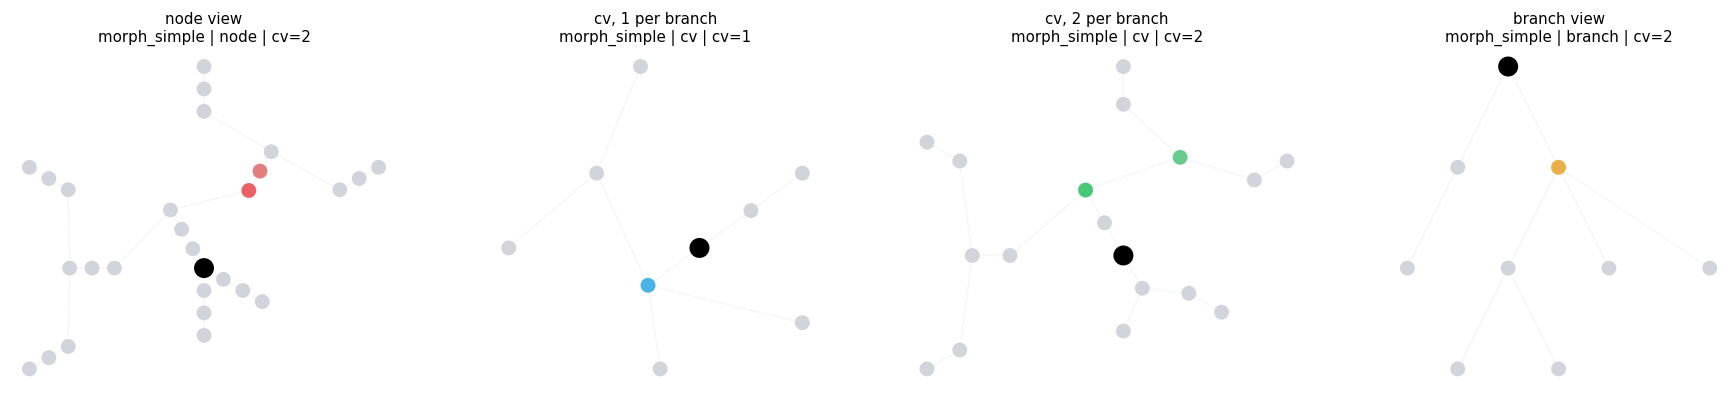

In [4]:
same_region = BranchSlice(branch_index=3, prox=0.10, dist=0.80)

compare_regions(
    morph_simple,
    [
        {'label': 'node view', 'expr': same_region, 'level': 'node', 'preset': 'dendrotweaks', 'layout': None},
        {'label': 'cv, 1 per branch', 'expr': same_region, 'level': 'cv', 'layout': 'twopi', 'cv_per_branch': 1},
        {'label': 'cv, 2 per branch', 'expr': same_region, 'level': 'cv', 'layout': 'twopi', 'cv_per_branch': 2},
        {'label': 'branch view', 'expr': same_region, 'level': 'branch', 'layout': 'dot'},
    ],
)


## 3. Region Filters

A region is a set of continuous branch intervals: `(branch_id, prox, dist)`.

Start with the small morphology so every selection is easy to inspect.


### 3.1 Explicit Regions

Use `AllRegion`, `EmptyRegion`, and `BranchSlice` when you already know the branch ids and normalized coordinates.


compare_regions defaults: morph=morph_simple level=cv layout=twopi cv_per_branch=1
  all branches                 morph=morph_simple level=cv     layout=twopi        cv_per_branch=1  intervals=   9 sample=((0, 0.0, 1.0), (1, 0.0, 1.0), (2, 0.0, 1.0), (3, 0.0, 1.0))
  branch 3: 10%-80%            morph=morph_simple level=cv     layout=twopi        cv_per_branch=1  intervals=   1 sample=((3, 0.1, 0.8),)
  two branch slices            morph=morph_simple level=cv     layout=twopi        cv_per_branch=1  intervals=   2 sample=((1, 0.0, 1.0), (3, 0.2, 0.8))
  empty                        morph=morph_simple level=cv     layout=twopi        cv_per_branch=1  intervals=   0 sample=()


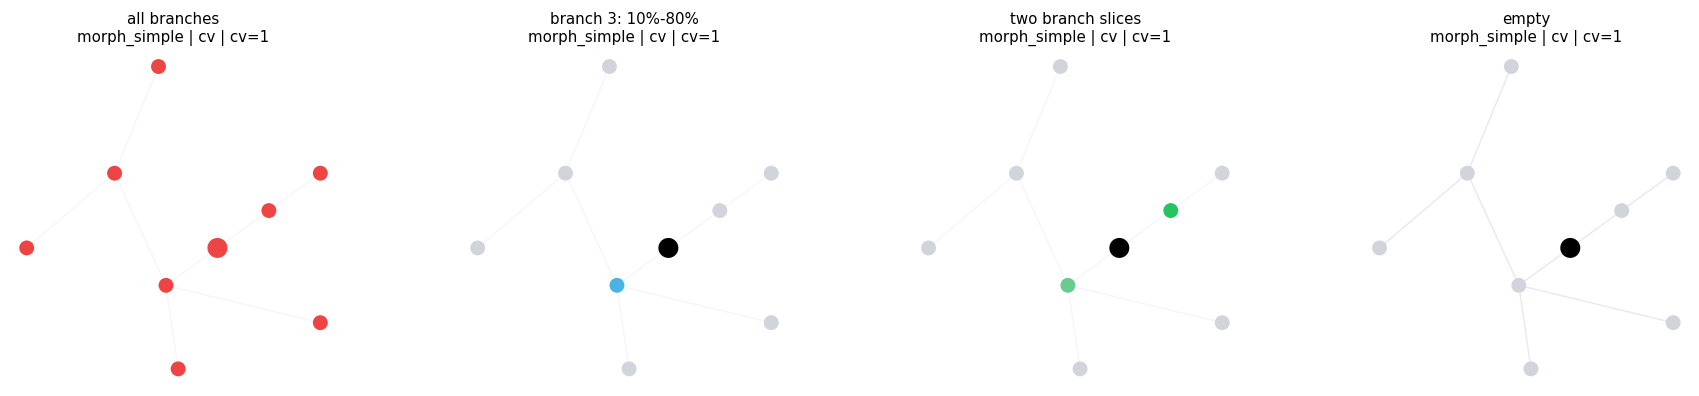

In [5]:
compare_regions(
    morph_simple,
    [
        ('all branches', AllRegion()),
        ('branch 3: 10%-80%', BranchSlice(branch_index=3, prox=0.10, dist=0.80)),
        ('two branch slices', BranchSlice(branch_index=[1, 3], prox=[0.0, 0.20], dist=[1.0, 0.80])),
        ('empty', EmptyRegion()),
    ],
    level='cv',
    layout='twopi',
    cv_per_branch=1,
)


### 3.2 Branch Metadata Predicates

Use `branch_in(...)` when the rule is equality or membership over branch metadata / topology.


compare_regions defaults: morph=morph_simple level=branch layout=dot cv_per_branch=2
  type == soma                 morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   1 sample=((0, 0.0, 1.0),)
  type == basal                morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   6 sample=((3, 0.0, 1.0), (4, 0.0, 1.0), (5, 0.0, 1.0), (6, 0.0, 1.0))
  children of branch 3         morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   3 sample=((4, 0.0, 1.0), (7, 0.0, 1.0), (8, 0.0, 1.0))
  order in {2, 3}              morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   6 sample=((2, 0.0, 1.0), (4, 0.0, 1.0), (5, 0.0, 1.0), (6, 0.0, 1.0))


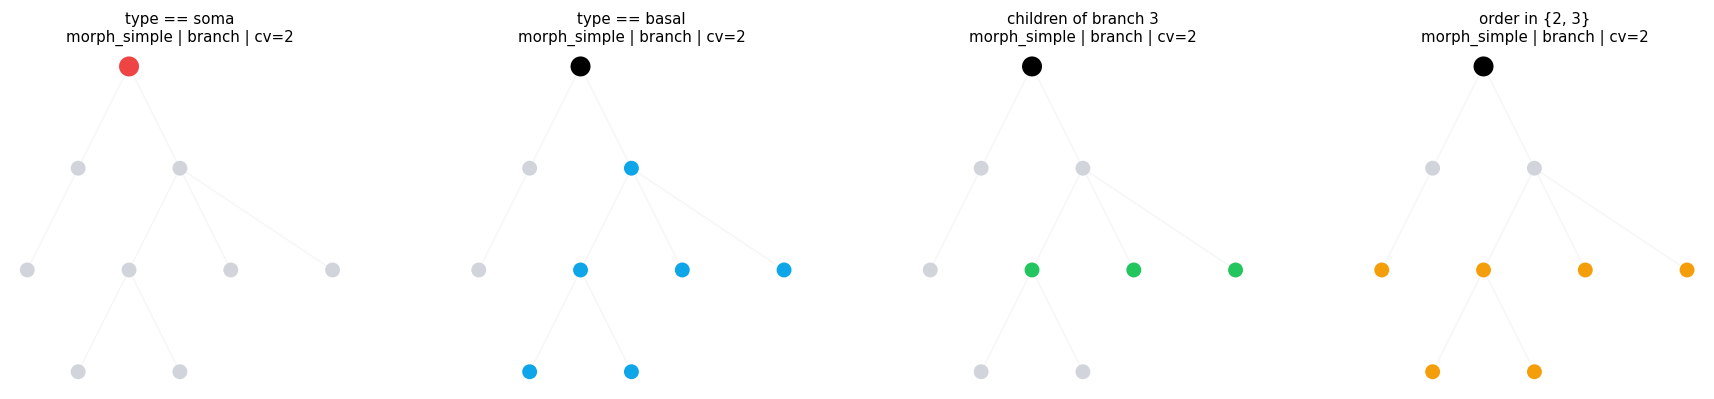

In [6]:
compare_regions(
    morph_simple,
    [
        ('type == soma', branch_in('type', 'soma')),
        ('type == basal', branch_in('type', 'basal_dendrite')),
        ('children of branch 3', branch_in('parent_id', {3})),
        ('order in {2, 3}', branch_in('branch_order', {2, 3})),
    ],
    level='branch',
    layout='dot',
)


### 3.3 Numeric and Quantity Ranges

Use `branch_range(...)` for numeric topology values and unit-carrying branch metrics.


compare_regions defaults: morph=morph_simple level=branch layout=dot cv_per_branch=2
  branch_id [1, 4]             morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   4 sample=((1, 0.0, 1.0), (2, 0.0, 1.0), (3, 0.0, 1.0), (4, 0.0, 1.0))
  length >= 20 um              morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   5 sample=((1, 0.0, 1.0), (3, 0.0, 1.0), (4, 0.0, 1.0), (5, 0.0, 1.0))
  mean_radius <= 1 um          morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   3 sample=((1, 0.0, 1.0), (2, 0.0, 1.0), (8, 0.0, 1.0))
  volume <= 80 um^3            morph=morph_simple level=branch layout=dot          cv_per_branch=2  intervals=   3 sample=((2, 0.0, 1.0), (6, 0.0, 1.0), (8, 0.0, 1.0))


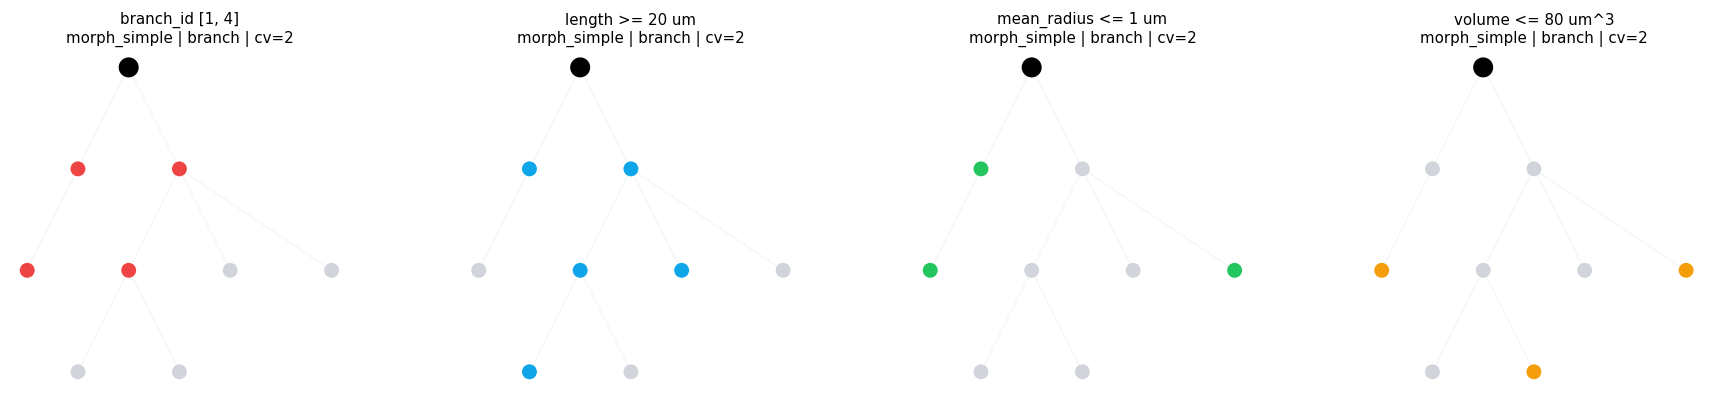

In [7]:
compare_regions(
    morph_simple,
    [
        ('branch_id [1, 4]', branch_range('branch_id', (1, 4), closed='both')),
        ('length >= 20 um', branch_range('length', (20.0 * u.um, None), closed='left')),
        ('mean_radius <= 1 um', branch_range('mean_radius', (None, 1.0 * u.um), closed='right')),
        ('volume <= 80 um^3', branch_range('volume', (None, 80.0 * (u.um ** 3)), closed='right')),
    ],
    level='branch',
    layout='dot',
)


### 3.4 Region Set Algebra

Region expressions compose with union, intersection, difference, and complement.


compare_regions defaults: morph=morph_pc level=cv layout=twopi cv_per_branch=2
  left | right                 morph=morph_pc     level=cv     layout=twopi        cv_per_branch=2  intervals=   1 sample=((3, 0.0, 1.0),)
  left & right                 morph=morph_pc     level=cv     layout=twopi        cv_per_branch=2  intervals=   1 sample=((3, 0.4, 0.6),)
  left - right                 morph=morph_pc     level=cv     layout=twopi        cv_per_branch=2  intervals=   1 sample=((3, 0.0, 0.4),)
  exclude.complement()         morph=morph_pc     level=cv     layout=twopi        cv_per_branch=2  intervals= 461 sample=((0, 0.0, 1.0), (2, 0.0, 1.0), (3, 0.0, 0.2), (3, 0.8, 1.0))


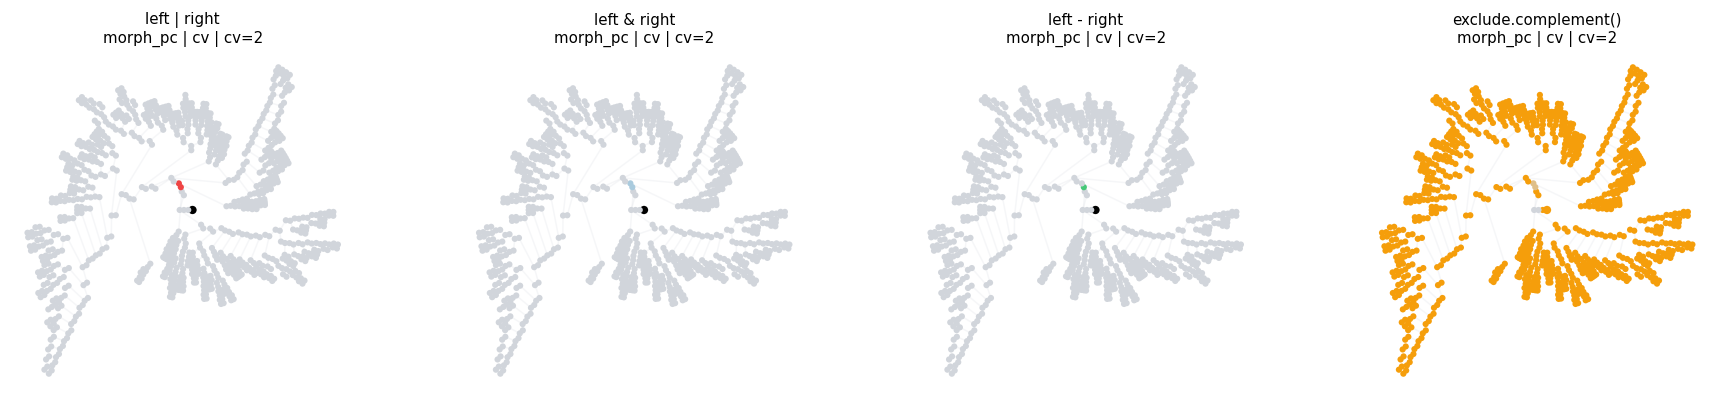

In [8]:
left = BranchSlice(branch_index=3, prox=0.00, dist=0.60)
right = BranchSlice(branch_index=3, prox=0.40, dist=1.00)
exclude = BranchSlice(branch_index=[1, 3], prox=[0.00, 0.20], dist=[1.00, 0.80])

compare_regions(
    morph_pc,
    [
        ('left | right', left | right),
        ('left & right', left & right),
        ('left - right', left - right),
        ('exclude.complement()', exclude.complement()),
    ],
    level='cv',
    layout='twopi',
    cv_per_branch=2,
)


### 3.5 Same Logic on `morph_io`

Once the filter expression is clear, the same calls work on a richer morphology.


compare_regions defaults: morph=morph_io level=branch layout=dot cv_per_branch=2
  basal branches               morph=morph_io     level=branch layout=dot          cv_per_branch=2  intervals=  25 sample=((6, 0.0, 1.0), (7, 0.0, 1.0), (8, 0.0, 1.0), (9, 0.0, 1.0))
  length >= 100 um             morph=morph_io     level=branch layout=dot          cv_per_branch=2  intervals=  10 sample=((8, 0.0, 1.0), (10, 0.0, 1.0), (11, 0.0, 1.0), (13, 0.0, 1.0))
  basal & long                 morph=morph_io     level=branch layout=dot          cv_per_branch=2  intervals=  10 sample=((8, 0.0, 1.0), (10, 0.0, 1.0), (11, 0.0, 1.0), (13, 0.0, 1.0))
  order [2, 4)                 morph=morph_io     level=branch layout=dot          cv_per_branch=2  intervals=  16 sample=((7, 0.0, 1.0), (8, 0.0, 1.0), (9, 0.0, 1.0), (12, 0.0, 1.0))


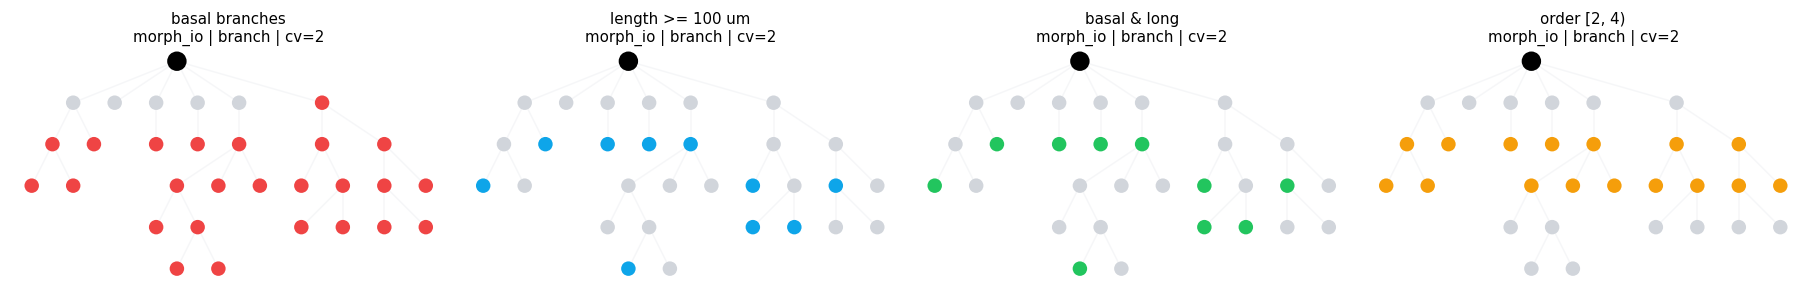

In [9]:
basal = branch_in('type', 'basal_dendrite')
long = branch_range('length', (100.0 * u.um, None), closed='left')
mid_order = branch_range('branch_order', (2, 4), closed='left')

compare_regions(
    morph_io,
    [
        ('basal branches', basal),
        ('length >= 100 um', long),
        ('basal & long', basal & long),
        ('order [2, 4)', mid_order),
    ],
    level='branch',
    layout='dot',
)


### 3.6 Same Logic on `morph_pc`

On a larger morphology, use the same small vocabulary: metadata predicates, metric ranges, and set algebra.


compare_regions defaults: morph=morph_pc level=branch layout=dot cv_per_branch=2
  order [6, 8)                 morph=morph_pc     level=branch layout=dot          cv_per_branch=2  intervals=  52 sample=((6, 0.0, 1.0), (7, 0.0, 1.0), (8, 0.0, 1.0), (9, 0.0, 1.0))
  length <= 5 um               morph=morph_pc     level=branch layout=dot          cv_per_branch=2  intervals= 113 sample=((7, 0.0, 1.0), (8, 0.0, 1.0), (9, 0.0, 1.0), (10, 0.0, 1.0))
  mean_radius <= 0.5 um        morph=morph_pc     level=branch layout=dot          cv_per_branch=2  intervals= 328 sample=((5, 0.0, 1.0), (6, 0.0, 1.0), (7, 0.0, 1.0), (8, 0.0, 1.0))
  deep & short                 morph=morph_pc     level=branch layout=dot          cv_per_branch=2  intervals=  18 sample=((7, 0.0, 1.0), (8, 0.0, 1.0), (9, 0.0, 1.0), (10, 0.0, 1.0))


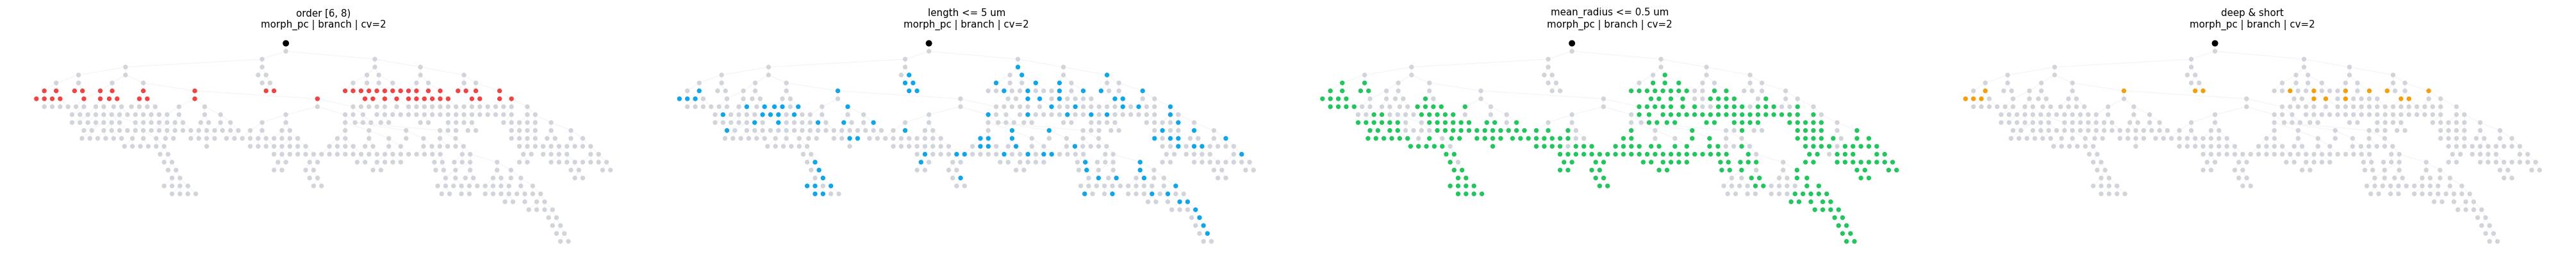

In [10]:
deep = branch_range('branch_order', (6, 8), closed='left')
short = branch_range('length', (None, 5.0 * u.um), closed='right')
thin = branch_range('mean_radius', (None, 0.5 * u.um), closed='right')

compare_regions(
    morph_pc,
    [
        ('order [6, 8)', deep),
        ('length <= 5 um', short),
        ('mean_radius <= 0.5 um', thin),
        ('deep & short', deep & short),
    ],
    level='branch',
    layout='dot',
    width=8.4,
    height=10.0,
)


## 4. Locset Filters

A locset is a set of points: `(branch_id, x)`.

Locsets are separate from regions because they mark point-process sites instead of continuous branch intervals.


### 4.1 Direct Point Selectors

Use direct locsets when you know the exact site or want built-in structural points.


compare_locsets defaults: morph=morph_simple level=node layout=kamada_kawai cv_per_branch=2
  root midpoint                morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   1 sample=('soma(0.5)',)
  at('soma', 1.0)              morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   1 sample=('soma(1)',)
  AtLocation('axon_0', 0.5)    morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   1 sample=('axon_0(0.5)',)
  branch points                morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   5 sample=('soma(0)', 'soma(1)', 'basal_dendrite_0(0)', 'basal_dendrite_0(1)')


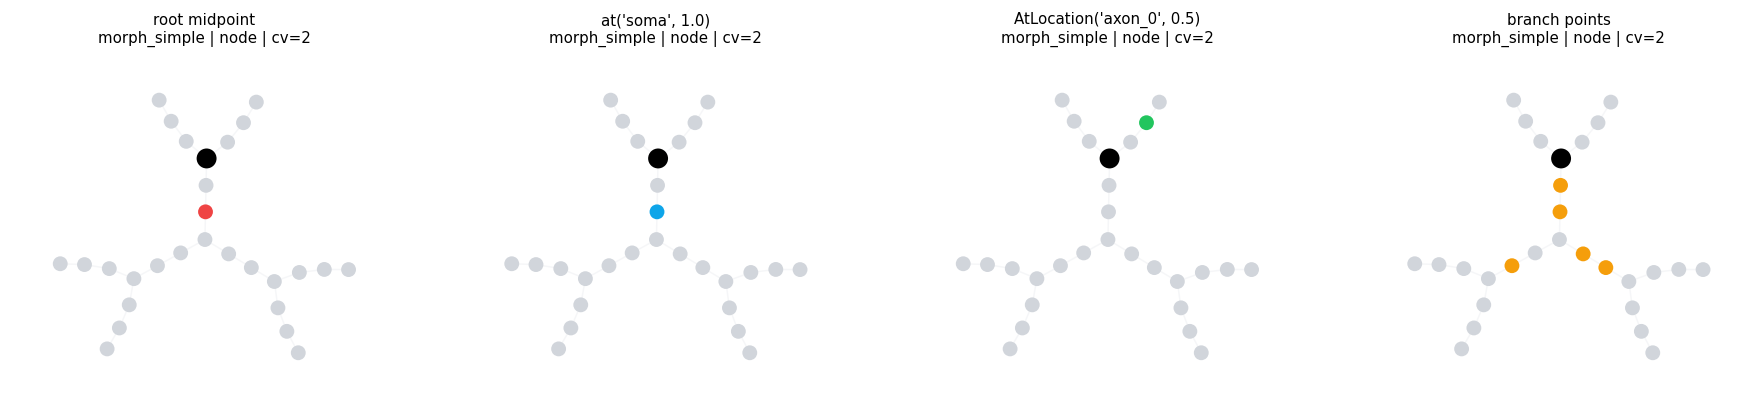

In [11]:
compare_locsets(
    morph_simple,
    [
        ('root midpoint', RootLocation(x=0.5)),
        ("at('soma', 1.0)", at('soma', 1.0)),
        ("AtLocation('axon_0', 0.5)", AtLocation(branch='axon_0', x=0.5)),
        ('branch points', BranchPoints()),
    ],
    level='node',
    layout='kamada_kawai',
)


### 4.2 Structural Locsets and Set Algebra

Locsets also compose with union, intersection, and difference.


compare_locsets defaults: morph=morph_simple level=node layout=kamada_kawai cv_per_branch=2
  terminals                    morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   5 sample=('axon_1(1)', 'basal_dendrite_2(1)', 'basal_dendrite_3(1)', 'basal_dendrite_4(1)')
  branch points                morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   5 sample=('soma(0)', 'soma(1)', 'basal_dendrite_0(0)', 'basal_dendrite_0(1)')
  branch_points | terminals    morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=  10 sample=('soma(0)', 'soma(1)', 'axon_1(1)', 'basal_dendrite_0(0)')
  terminals - first            morph=morph_simple level=node   layout=kamada_kawai cv_per_branch=2  points=   4 sample=('basal_dendrite_2(1)', 'basal_dendrite_3(1)', 'basal_dendrite_4(1)', 'basal_dendrite_5(1)')


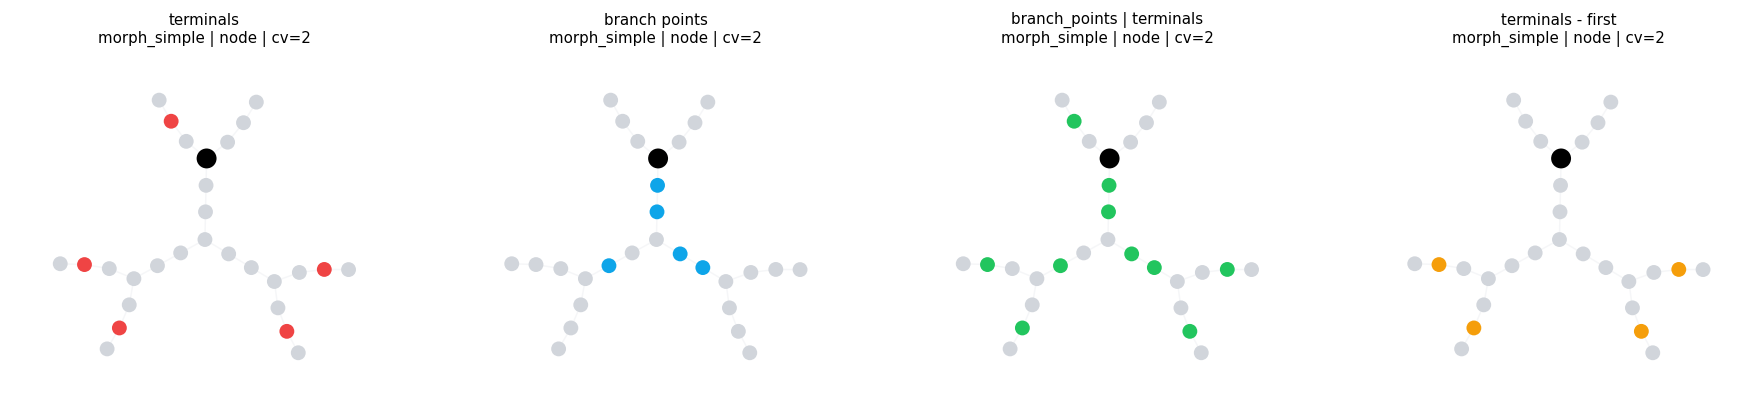

In [12]:
branch_points = BranchPoints()
terminals = Terminals()
first_terminal = morph_simple.select(terminals).points[0]

compare_locsets(
    morph_simple,
    [
        ('terminals', terminals),
        ('branch points', branch_points),
        ('branch_points | terminals', branch_points | terminals),
        ('terminals - first', terminals - at(first_terminal[0], first_terminal[1])),
    ],
    level='node',
    layout='kamada_kawai',
)


### 4.3 Sampling Points from a Region

`UniformSamples` and `RandomSamples` take a region expression, then choose points inside it.


same random seed gives same points: True

compare_locsets defaults: morph=morph_io level=cv layout=twopi cv_per_branch=2
  terminals                    morph=morph_io     level=cv     layout=twopi        cv_per_branch=2  points=  17 sample=('soma_1(1)', 'basal_dendrite_2(1)', 'basal_dendrite_4(1)', 'basal_dendrite_5(1)')
  uniform samples              morph=morph_io     level=cv     layout=twopi        cv_per_branch=2  points=   8 sample=('basal_dendrite_2(0.405)', 'basal_dendrite_4(0.537347)', 'basal_dendrite_7(0.548927)', 'basal_dendrite_12(0.435744)')
  random seed 7                morph=morph_io     level=cv     layout=twopi        cv_per_branch=2  points=   8 sample=('soma_1(0.504548)', 'basal_dendrite_5(0.278426)', 'basal_dendrite_7(0.25487)', 'basal_dendrite_15(0.797069)')
  same random seed             morph=morph_io     level=cv     layout=twopi        cv_per_branch=2  points=   8 sample=('soma_1(0.504548)', 'basal_dendrite_5(0.278426)', 'basal_dendrite_7(0.25487)', 'basal_den

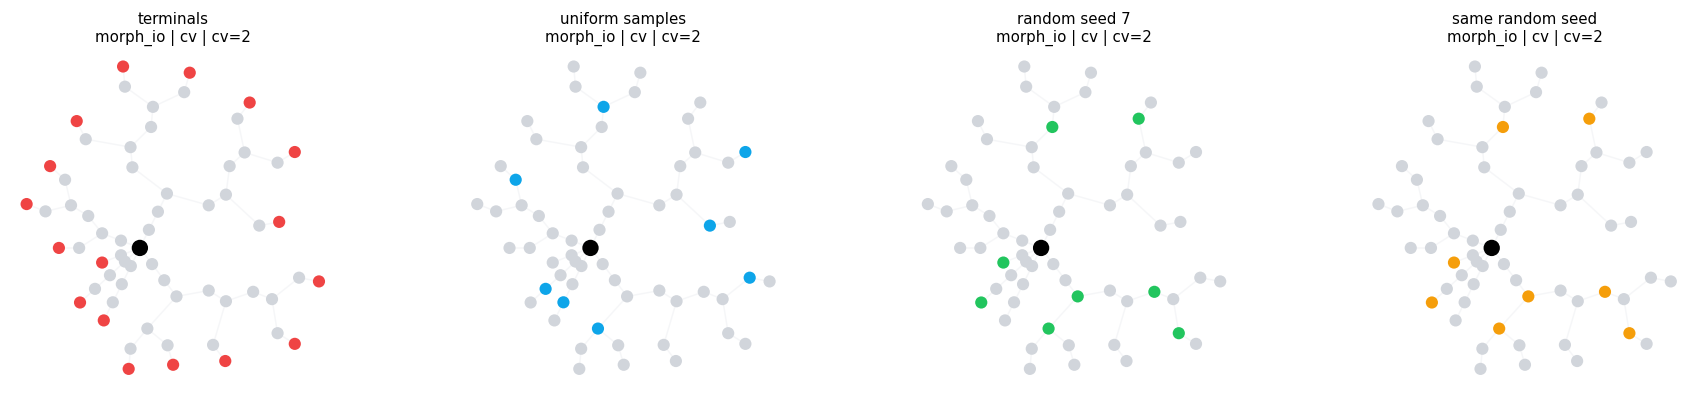

In [13]:
sampling_region = branch_range('branch_order', (1, None), closed='left')
uniform = UniformSamples(region=sampling_region, count=8)
random_a = RandomSamples(region=sampling_region, count=8, seed=7)
random_b = RandomSamples(region=sampling_region, count=8, seed=7)

print('same random seed gives same points:', morph_io.select(random_a).points == morph_io.select(random_b).points)
print()

compare_locsets(
    morph_io,
    [
        ('terminals', Terminals()),
        ('uniform samples', uniform),
        ('random seed 7', random_a),
        ('same random seed', random_b),
    ],
    level='cv',
    layout='twopi',
)


### 4.4 Locsets on `morph_pc`

The same locset calls work on the larger morphology. The filter logic stays small; only the morphology changes.


compare_locsets defaults: morph=morph_pc level=cv layout=dot cv_per_branch=2
  branch points                morph=morph_pc     level=cv     layout=dot          cv_per_branch=2  points= 228 sample=('dendrite_0(1)', 'dendrite_1(1)', 'dendrite_2(1)', 'dendrite_3(1)')
  terminals                    morph=morph_pc     level=cv     layout=dot          cv_per_branch=2  points= 229 sample=('dendrite_6(1)', 'dendrite_7(1)', 'dendrite_10(1)', 'dendrite_11(1)')
  uniform deep samples         morph=morph_pc     level=cv     layout=dot          cv_per_branch=2  points=  12 sample=('dendrite_8(0.333287)', 'dendrite_20(0.845796)', 'dendrite_80(0.793563)', 'dendrite_88(0.921427)')
  random deep samples          morph=morph_pc     level=cv     layout=dot          cv_per_branch=2  points=  12 sample=('dendrite_17(0.284201)', 'dendrite_17(0.430628)', 'dendrite_20(0.97346)', 'dendrite_26(0.292721)')


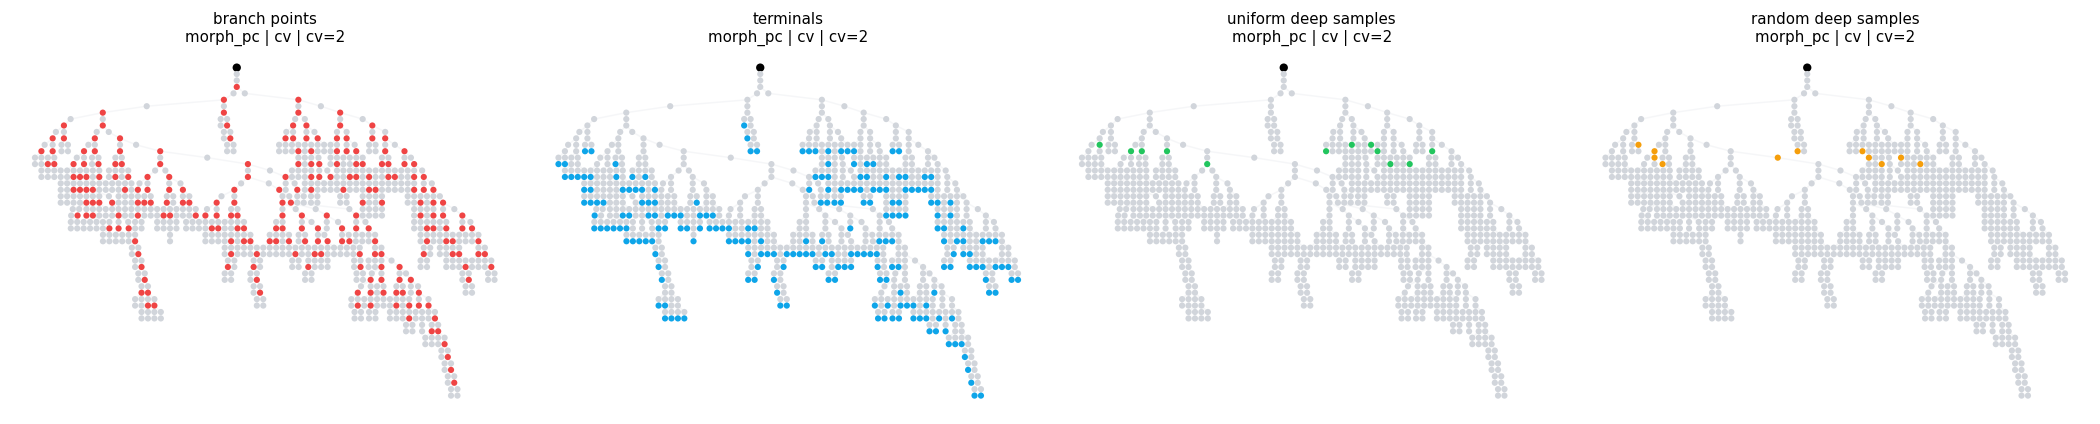

In [14]:
pc_sampling_region = branch_range('branch_order', (6, 8), closed='left')

compare_locsets(
    morph_pc,
    [
        ('branch points', BranchPoints()),
        ('terminals', Terminals()),
        ('uniform deep samples', UniformSamples(region=pc_sampling_region, count=12)),
        ('random deep samples', RandomSamples(region=pc_sampling_region, count=12, seed=3)),
    ],
    level='cv',
    layout='dot',
    width=4.4,
    height=4.0,
)


## 5. Filters as Cell Inputs

The same expressions are the user-facing handles for mechanism placement.


Cell(root='soma', n_cv=18, n_point=28, initialized=True)
painted region intervals: ((1, 0.0, 1.0), (2, 0.0, 1.0))
probe site points      : ('soma(0.5)',)


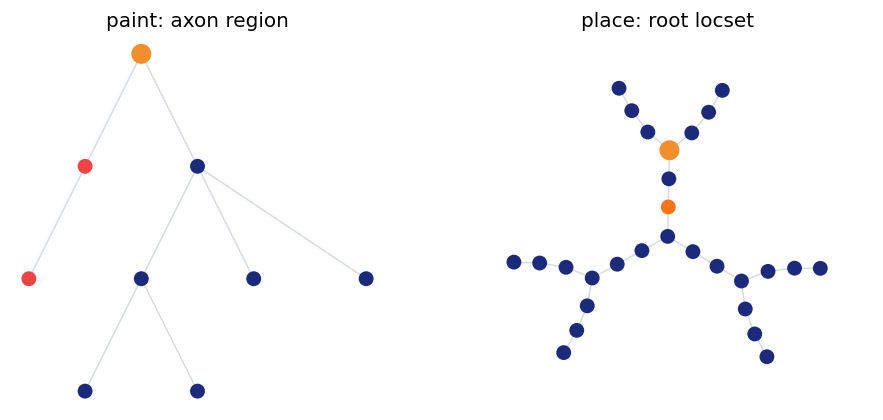

In [15]:
cell = Cell(morph_simple, cv_policy=CVPerBranch(cv_per_branch=2))
axon_region = branch_in('type', 'axon')
probe_site = RootLocation(0.5)

cell.paint(
    axon_region,
    mech.Channel('IL', g_max=0.03 * (u.mS / u.cm ** 2), E=-65.0 * u.mV),
)
cell.place(probe_site, mech.StateProbe())
cell.init_state()

print(cell)
print('painted region intervals:', morph_simple.select(axon_region).intervals)
print('probe site points      :', morph_simple.select(probe_site).display_names)

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.6))
cell.vis_topology(level='branch', layout='dot', region=axon_region, ax=axes[0], show=False)
axes[0].set_title('paint: axon region')
cell.vis_topology(level='node', layout='kamada_kawai', layout_scale=1.5, locset=probe_site, ax=axes[1], show=False, highlight_color='#f97316')
axes[1].set_title('place: root locset')
plt.tight_layout()
plt.show()


## 6. Quick Reference

Plot configuration lives in the global constants near the top of the notebook. You can also override per panel with dictionaries:

```python
compare_regions(
    morph_simple,
    [
        {'label': 'cv view', 'expr': expr, 'level': 'cv', 'layout': 'twopi', 'cv_per_branch': 2},
        {'label': 'branch view', 'expr': expr, 'level': 'branch', 'layout': 'dot'},
    ],
)
```

Implemented region selectors:

| API | Use when |
| --- | --- |
| `AllRegion()` / `EmptyRegion()` | select all / no branch intervals |
| `BranchSlice(...)` | select explicit `(branch_id, prox, dist)` intervals |
| `branch_in(property, values)` | match branch metadata, topology, or scalar metric values |
| `branch_range(property, bounds, closed=...)` | filter numeric or `brainunit` quantity-valued branch properties |
| `left | right`, `left & right`, `left - right`, `expr.complement()` | compose region expressions |

Supported scalar branch properties:

- metadata / topology: `branch_id`, `name`, `type`, `parent_id`, `n_children`, `branch_order`, `n_tapers`
- geometry metrics: `length`, `mean_radius`, `area`, `volume`

Implemented locset selectors:

| API | Use when |
| --- | --- |
| `RootLocation(x)` | choose a point on branch `0` |
| `AtLocation(branch, x)` / `at(branch, x)` | choose an explicit branch-local point |
| `BranchPoints()` | choose branch-point sites on the parent side |
| `Terminals()` | choose terminal branch distal ends |
| `UniformSamples(region, count)` | evenly sample points from a region |
| `RandomSamples(region, count, seed)` | reproducibly sample random points from a region |
| `left | right`, `left & right`, `left - right` | compose locset expressions |

Exported but not implemented yet: `RadiusRangeRegion`, `TreeDistanceRegion`, `EuclideanDistanceRegion`, `SubtreeRegion`, `RegionAnchors`, and `StepSamples`.
